# EDA — Thermal Drone YOLOv8 Dataset
### Calibrating a Target-Agnostic Diffusion Loss for Super-Resolution (ResShift / DifIISR)

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import json
import zipfile
from pathlib import Path
from scipy import signal, ndimage

%matplotlib inline
sns.set_style("whitegrid")
np.random.seed(42)

# ── User-editable constants ───────────────────────────────────────────────────
ZIP_PATH      = "thermal-drone.v1i.yolov8.zip"
EXTRACT_DIR   = "eda_results/dataset"
RESULTS_DIR   = "eda_results"
EXPAND_FACTOR = 2.5   # ring BBox expansion multiplier

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results directory ready: {os.path.abspath(RESULTS_DIR)}")

Results directory ready: c:\projects\drones\eda_results


## Cell 2 — Dataset Loading & ResShift Preprocessing
Extracts the ZIP once, discovers all splits (train/valid/test), applies the full per-image pipeline:
`I_HR → I_Bicubic_x4 → target patches (HR + Bicubic) → background ring (annulus mask)`

In [3]:

# ── Step 2a: Extract ZIP once ─────────────────────────────────────────────────
if not os.path.exists(EXTRACT_DIR):
    print("Extracting dataset ZIP...")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(EXTRACT_DIR)
    print("Extraction complete.")
else:
    print(f"Dataset already extracted: {EXTRACT_DIR}")


def _build_label_path(img_path: str) -> str:
    """Derive label .txt path from image path (images/ → labels/)."""
    p = Path(img_path)
    return str(p.parent.parent / "labels" / p.with_suffix(".txt").name)


def _parse_yolo_labels(label_path: str, H: int, W: int):
    """Return list of pixel BBoxes (x1,y1,x2,y2); skip degenerate boxes."""
    bboxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            _, cx, cy, bw, bh = map(float, parts[:5])
            px_cx, px_cy = cx * W, cy * H
            px_w,  px_h  = bw * W, bh * H
            x1 = int(px_cx - px_w / 2);  x2 = int(px_cx + px_w / 2)
            y1 = int(px_cy - px_h / 2);  y2 = int(px_cy + px_h / 2)
            # [C2] clip to image bounds
            x1, x2 = int(np.clip(x1, 0, W)), int(np.clip(x2, 0, W))
            y1, y2 = int(np.clip(y1, 0, H)), int(np.clip(y2, 0, H))
            # [C6] skip degenerate boxes
            if (x2 - x1) < 2 or (y2 - y1) < 2:
                continue
            bboxes.append((x1, y1, x2, y2, px_cx, px_cy, px_w, px_h))
    return bboxes


def _make_bg_ring(img: np.ndarray, x1, y1, x2, y2,
                  px_cx, px_cy, px_w, px_h) -> np.ndarray:
    """[C2]+[C3] Extract expanded ring patch, zero out the target centre."""
    H, W = img.shape
    half_rw = int(px_w * EXPAND_FACTOR / 2)
    half_rh = int(px_h * EXPAND_FACTOR / 2)
    rx1 = int(np.clip(px_cx - half_rw, 0, W))
    ry1 = int(np.clip(px_cy - half_rh, 0, H))
    rx2 = int(np.clip(px_cx + half_rw, 0, W))
    ry2 = int(np.clip(px_cy + half_rh, 0, H))
    if (rx2 - rx1) < 2 or (ry2 - ry1) < 2:
        return None
    bg = img[ry1:ry2, rx1:rx2].copy()
    # local coords of target inside ring crop
    lx1 = max(x1 - rx1, 0);  lx2 = min(x2 - rx1, bg.shape[1])
    ly1 = max(y1 - ry1, 0);  ly2 = min(y2 - ry1, bg.shape[0])
    bg[ly1:ly2, lx1:lx2] = 0  # [C3] zero out target — annulus mask
    return bg


def process_image(img_path: str):
    """Full per-image pipeline. Returns dict or None if no valid targets."""
    label_path = _build_label_path(img_path)
    # [C6] skip missing or empty label files
    if not os.path.exists(label_path) or os.path.getsize(label_path) == 0:
        return None

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    H, W = img.shape

    # [C1] Exact Bicubic degradation as in DifIISR / ResShift protocol
    lr      = cv2.resize(img, (max(W // 4, 1), max(H // 4, 1)),
                         interpolation=cv2.INTER_CUBIC)
    bicubic = cv2.resize(lr,  (W, H), interpolation=cv2.INTER_CUBIC)

    raw_boxes = _parse_yolo_labels(label_path, H, W)
    if not raw_boxes:
        return None

    target_patches_hr, target_patches_bicubic, bg_patches, bboxes = [], [], [], []
    for (x1, y1, x2, y2, px_cx, px_cy, px_w, px_h) in raw_boxes:
        tgt_hr  = img[y1:y2, x1:x2].copy()
        tgt_bic = bicubic[y1:y2, x1:x2].copy()
        bg      = _make_bg_ring(img, x1, y1, x2, y2, px_cx, px_cy, px_w, px_h)
        if bg is None:
            continue
        target_patches_hr.append(tgt_hr)
        target_patches_bicubic.append(tgt_bic)
        bg_patches.append(bg)
        bboxes.append((x1, y1, x2, y2))

    if not bboxes:
        return None

    # [C5] store only patches + path — full img/bicubic freed here
    return {
        "path":                   img_path,
        "bboxes":                 bboxes,
        "target_patches_hr":      target_patches_hr,
        "target_patches_bicubic": target_patches_bicubic,
        "bg_patches":             bg_patches,
    }


# ── Step 2b: Discover all images across train/valid/test ──────────────────────
img_paths = sorted(
    glob.glob(os.path.join(EXTRACT_DIR, "**", "images", "*.jpg"), recursive=True) +
    glob.glob(os.path.join(EXTRACT_DIR, "**", "images", "*.png"), recursive=True)
)

# ── Step 2c: Run pipeline + collect pure-background paths ────────────────────
# bg_only_paths: empty-label images — crops deferred to Cell 3 (size matched to median drone bbox)
dataset, bg_only_paths, skipped = [], [], 0
for img_path in img_paths:
    lp = _build_label_path(img_path)
    if os.path.exists(lp) and os.path.getsize(lp) == 0:
        bg_only_paths.append(img_path)
        continue
    record = process_image(img_path)
    if record:
        dataset.append(record)
    else:
        skipped += 1

total_targets = sum(len(r["bboxes"]) for r in dataset)
print(f"Loaded  : {len(dataset)} images  ({total_targets} valid targets)")
print(f"BG-only : {len(bg_only_paths)} pure-background images (crops deferred to Cell 3)")
print(f"Skipped : {skipped} images (no label / degenerate bbox)")


Dataset already extracted: eda_results/dataset
Loaded  : 6104 images  (6108 valid targets)
BG-only : 926 pure-background images (crops deferred to Cell 3)
Skipped : 2 images (no label / degenerate bbox)


In [3]:
# Diagnostic: break down skip reasons
reason_no_label   = 0
reason_empty_label = 0
reason_no_valid_bbox = 0
reason_bad_image  = 0

for p in img_paths:
    lp = _build_label_path(p)
    if not os.path.exists(lp):
        reason_no_label += 1
        continue
    if os.path.getsize(lp) == 0:
        reason_empty_label += 1
        continue
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        reason_bad_image += 1
        continue
    H, W = img.shape
    boxes = _parse_yolo_labels(lp, H, W)
    if not boxes:
        reason_no_valid_bbox += 1

print(f"No label file found : {reason_no_label}")
print(f"Empty label file    : {reason_empty_label}")
print(f"All BBoxes degenerate (w/h < 2px): {reason_no_valid_bbox}")
print(f"Unreadable image    : {reason_bad_image}")
print(f"Total skipped       : {reason_no_label + reason_empty_label + reason_no_valid_bbox + reason_bad_image}")

No label file found : 0
Empty label file    : 926
All BBoxes degenerate (w/h < 2px): 2
Unreadable image    : 0
Total skipped       : 928


## Cell 3 — Morphological Size Analysis
Computes drone target dimensions, derives `recommended_kernel_size`, then crops
`bg_pure_patches` from background-only images at the **same size** as mean drone bbox
for a fair comparison in Cells 4 & 6.

Drone target area percentiles (physical range = distance variation):
  P 5  →         30 px²   (side ≈    5.5 px)
  P10  →         40 px²   (side ≈    6.3 px)
  P25  →        110 px²   (side ≈   10.5 px)
  P50  →        950 px²   (side ≈   30.8 px)
  P75  →       9215 px²   (side ≈   96.0 px)
  P90  →      81736 px²   (side ≈  285.9 px)
  P95  →      96928 px²   (side ≈  311.3 px)
  P99  →     117795 px²   (side ≈  343.2 px)

mean_drone_size    = 18251 px²  (pulled high by close-range targets)
median_drone_size  = 950 px²  (representative of typical target)
recommended_kernel_size = 31 px  (median-based, odd)


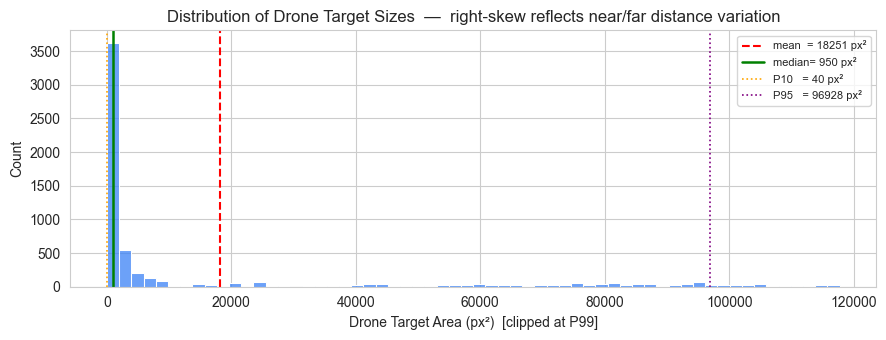


bg_pure_patches : 2778 crops  (each 31×31 px — matches median drone size)


In [4]:
N_BG_CROPS_PER_IMAGE = 3  # random crops per pure-background image

# ── 3a: Collect BBox dimensions ───────────────────────────────────────────────
widths, heights, areas, aspects = [], [], [], []
for rec in dataset:
    for (x1, y1, x2, y2) in rec["bboxes"]:
        w, h = x2 - x1, y2 - y1
        widths.append(w);  heights.append(h)
        areas.append(w * h)
        aspects.append(w / h if h > 0 else 0)

areas   = np.array(areas)
widths  = np.array(widths)
heights = np.array(heights)

mean_drone_size   = float(np.mean(areas))
median_drone_size = float(np.median(areas))
min_drone_size    = float(np.min(areas))

# Percentile table — documents full scale range (near/far drones)
pcts = [5, 10, 25, 50, 75, 90, 95, 99]
pct_vals = np.percentile(areas, pcts)
print("Drone target area percentiles (physical range = distance variation):")
for p, v in zip(pcts, pct_vals):
    print(f"  P{p:>2}  →  {v:>9.0f} px²   (side ≈ {np.sqrt(v):>6.1f} px)")

median_side = float(np.sqrt(median_drone_size))
mean_side   = float(np.mean(np.sqrt(areas)))
# median-based kernel is robust to near/far outliers
recommended_kernel_size = max(3, int(median_side // 2) * 2 + 1)

print(f"\nmean_drone_size    = {mean_drone_size:.0f} px²  (pulled high by close-range targets)")
print(f"median_drone_size  = {median_drone_size:.0f} px²  (representative of typical target)")
print(f"recommended_kernel_size = {recommended_kernel_size} px  (median-based, odd)")

# ── 3b: Histogram — full distribution preserved as documented finding ─────────
fig, ax = plt.subplots(figsize=(9, 3.5))
display_areas = areas[areas <= pct_vals[-1]]  # clip at P99 to avoid axis collapse
sns.histplot(display_areas, bins=60, ax=ax, color="#3b82f6", edgecolor="white")
ax.axvline(mean_drone_size,   color="red",    ls="--", lw=1.5, label=f"mean  = {mean_drone_size:.0f} px²")
ax.axvline(median_drone_size, color="green",  ls="-",  lw=1.8, label=f"median= {median_drone_size:.0f} px²")
ax.axvline(pct_vals[1],       color="orange", ls=":",  lw=1.2, label=f"P10   = {pct_vals[1]:.0f} px²")
ax.axvline(pct_vals[-2],      color="purple", ls=":",  lw=1.2, label=f"P95   = {pct_vals[-2]:.0f} px²")
ax.set_xlabel("Drone Target Area (px²)  [clipped at P99]")
ax.set_ylabel("Count")
ax.set_title("Distribution of Drone Target Sizes  —  right-skew reflects near/far distance variation")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cell3_size_histogram.png"), dpi=150)
plt.show()

# ── 3c: bg_pure_patches — median-matched size for fair comparison ─────────────
crop_side = max(4, int(round(median_side)))
bg_pure_patches = []
rng = np.random.default_rng(42)

for bg_path in bg_only_paths:
    img = cv2.imread(bg_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    H, W = img.shape
    if H < crop_side or W < crop_side:
        continue
    for _ in range(N_BG_CROPS_PER_IMAGE):
        y0 = int(rng.integers(0, H - crop_side))
        x0 = int(rng.integers(0, W - crop_side))
        bg_pure_patches.append(img[y0:y0 + crop_side, x0:x0 + crop_side].copy())

print(f"\nbg_pure_patches : {len(bg_pure_patches)} crops  "
      f"(each {crop_side}×{crop_side} px — matches median drone size)")

## Cell 4 — EDA Patch Extraction
Uniform 61×61 Bicubic-LR patches for all EDA analyses.
- Drone: filtered to bbox_area ≤ PATCH_CORE² — drone fits inside core, ring is clean sky.
- Sky: same Bicubic-LR process, random crops, same virtual core/ring split.

In [5]:
# ── Patch geometry derived from Cell 3 ────────────────────────────────────────
PATCH_CORE  = recommended_kernel_size       # 31 px — median drone side (odd)
PATCH_OUTER = 2 * PATCH_CORE - 1           # 61 px — total EDA patch
HALF_OUTER  = PATCH_OUTER // 2             # 30
HALF_CORE   = PATCH_CORE  // 2             # 15
# drone must fit inside core so ring pixels are uncontaminated sky
AREA_MAX    = PATCH_CORE ** 2              # 961 px² ≈ P50

_ci = HALF_OUTER - HALF_CORE              # 15 — core start index in 61×61
_co = _ci + PATCH_CORE                    # 46 — core end index (exclusive)

def patch_core(p):
    return p[_ci:_co, _ci:_co]

def patch_ring_flat(p):
    mask = np.ones((PATCH_OUTER, PATCH_OUTER), dtype=bool)
    mask[_ci:_co, _ci:_co] = False
    return p[mask].astype(np.float32)

# ── 4a: Drone EDA patches — Bicubic-LR, small drones only ────────────────────
eda_drone_patches = []
skipped_large = skipped_edge = 0

for rec in dataset:
    img = cv2.imread(rec["path"], cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    H, W = img.shape
    lr      = cv2.resize(img, (max(W // 4, 1), max(H // 4, 1)), interpolation=cv2.INTER_CUBIC)
    bicubic = cv2.resize(lr,  (W, H),                            interpolation=cv2.INTER_CUBIC)
    for (x1, y1, x2, y2) in rec["bboxes"]:
        if (x2 - x1) * (y2 - y1) > AREA_MAX:
            skipped_large += 1
            continue
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        r0, r1 = cy - HALF_OUTER, cy + HALF_OUTER + 1
        c0, c1 = cx - HALF_OUTER, cx + HALF_OUTER + 1
        if r0 < 0 or r1 > H or c0 < 0 or c1 > W:
            skipped_edge += 1
            continue
        eda_drone_patches.append(bicubic[r0:r1, c0:c1].copy())

print(f"Drone EDA patches : {len(eda_drone_patches)}")
print(f"  skipped (too large) : {skipped_large}")
print(f"  skipped (near edge) : {skipped_edge}")

# ── 4b: Sky EDA patches — same Bicubic-LR process, random 61×61 crops ────────
eda_sky_patches = []
rng = np.random.default_rng(42)

for bg_path in bg_only_paths:
    img = cv2.imread(bg_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    H, W = img.shape
    if H < PATCH_OUTER or W < PATCH_OUTER:
        continue
    lr      = cv2.resize(img, (max(W // 4, 1), max(H // 4, 1)), interpolation=cv2.INTER_CUBIC)
    bicubic = cv2.resize(lr,  (W, H),                            interpolation=cv2.INTER_CUBIC)
    for _ in range(N_BG_CROPS_PER_IMAGE):
        r0 = int(rng.integers(0, H - PATCH_OUTER))
        c0 = int(rng.integers(0, W - PATCH_OUTER))
        eda_sky_patches.append(bicubic[r0:r0 + PATCH_OUTER, c0:c0 + PATCH_OUTER].copy())

print(f"Sky EDA patches   : {len(eda_sky_patches)}")
print(f"\nGeometry : outer={PATCH_OUTER}×{PATCH_OUTER}  core={PATCH_CORE}×{PATCH_CORE}  ring_width={(PATCH_OUTER-PATCH_CORE)//2} px")
print(f"Filter   : bbox area ≤ {AREA_MAX} px²  (drone fits inside core)")

Drone EDA patches : 3052
  skipped (too large) : 3045
  skipped (near edge) : 11
Sky EDA patches   : 2778

Geometry : outer=61×61  core=31×31  ring_width=15 px
Filter   : bbox area ≤ 961 px²  (drone fits inside core)


In [6]:
# ── 5: Explicit core/ring split with source labels ─────────────────────────────
# This cell must run before any metrics so each patch keeps its provenance.

PATCH_CORE_SIDE = 31
PATCH_RING_SIZE = PATCH_OUTER * PATCH_OUTER - PATCH_CORE_SIDE * PATCH_CORE_SIDE

assert PATCH_OUTER == 61, "Expected a 61x61 patch geometry"
assert PATCH_CORE == PATCH_CORE_SIDE, "Expected a 31x31 core geometry"
assert PATCH_RING_SIZE == 2760, "Expected a 2760-pixel background ring"


def split_patch_into_core_and_ring(patch: np.ndarray):
    """Return the centered 31x31 core and flattened outer ring for one 61x61 patch."""
    if patch.shape != (PATCH_OUTER, PATCH_OUTER):
        return None, None
    core = patch[_ci:_co, _ci:_co].copy()
    ring = patch_ring_flat(patch).copy()
    return core, ring


def build_source_split_records(patches, source_name: str):
    """Attach source labels to each patch and keep split views for downstream metrics."""
    records = []
    malformed = 0
    for patch in patches:
        core, ring = split_patch_into_core_and_ring(patch)
        if core is None or ring is None:
            malformed += 1
            continue
        if core.shape != (PATCH_CORE, PATCH_CORE):
            malformed += 1
            continue
        if ring.size != PATCH_RING_SIZE:
            malformed += 1
            continue
        records.append({
            "source": source_name,
            "patch": patch,
            "core": core,
            "ring": ring,
        })
    return records, malformed


drone_patch_records, drone_malformed = build_source_split_records(eda_drone_patches, "drone")
sky_patch_records, sky_malformed = build_source_split_records(eda_sky_patches, "sky")

# Backward-compatible derived collections with explicit provenance.
drone_core_patches = [rec["core"] for rec in drone_patch_records]
drone_ring_patches = [rec["ring"] for rec in drone_patch_records]
sky_core_patches = [rec["core"] for rec in sky_patch_records]
sky_ring_patches = [rec["ring"] for rec in sky_patch_records]

all_patch_records = drone_patch_records + sky_patch_records
all_core_patches = drone_core_patches + sky_core_patches
all_ring_patches = drone_ring_patches + sky_ring_patches
all_patch_sources = [rec["source"] for rec in all_patch_records]

print(f"Drone patches split: {len(drone_patch_records)} valid, {drone_malformed} malformed")
print(f"Sky patches split  : {len(sky_patch_records)} valid, {sky_malformed} malformed")
print(f"Combined records    : {len(all_patch_records)} total")
print(f"Core shape check    : {all_core_patches[0].shape if all_core_patches else 'n/a'}")
print(f"Ring size check     : {all_ring_patches[0].size if all_ring_patches else 'n/a'}")


Drone patches split: 3052 valid, 0 malformed
Sky patches split  : 2778 valid, 0 malformed
Combined records    : 5830 total
Core shape check    : (31, 31)
Ring size check     : 2760


In [7]:
# ── 6: Persist analysis-ready drone/sky splits ─────────────────────────────────
# Save source-aware patch records so later metric cells can reload them directly.

from dataclasses import asdict, dataclass
from datetime import datetime


EDA_EXPORT_DIR = os.path.join(RESULTS_DIR, "eda_exports")
os.makedirs(EDA_EXPORT_DIR, exist_ok=True)


@dataclass
class PatchRecord:
    source: str
    index: int
    patch_shape: tuple
    core_shape: tuple
    ring_size: int
    core: np.ndarray
    ring: np.ndarray


analysis_records = []
for source_name, patch_records in (("drone", drone_patch_records), ("sky", sky_patch_records)):
    for index, rec in enumerate(patch_records):
        analysis_records.append(PatchRecord(
            source=source_name,
            index=index,
            patch_shape=tuple(rec["patch"].shape),
            core_shape=tuple(rec["core"].shape),
            ring_size=int(rec["ring"].size),
            core=rec["core"].astype(np.uint8, copy=False),
            ring=rec["ring"].astype(np.uint8, copy=False),
        ))

save_payload = {
    "created_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "patch_outer": int(PATCH_OUTER),
    "patch_core": int(PATCH_CORE),
    "ring_size": int(PATCH_RING_SIZE),
    "drone_count": int(len(drone_patch_records)),
    "sky_count": int(len(sky_patch_records)),
    "records": [
        {
            "source": rec.source,
            "index": int(rec.index),
            "patch_shape": list(rec.patch_shape),
            "core_shape": list(rec.core_shape),
            "ring_size": int(rec.ring_size),
        }
        for rec in analysis_records
    ],
}

# Store analysis data in a compact NumPy archive for easy reuse.
np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "patch_records.npz"),
    drone_core=np.array(drone_core_patches, dtype=np.uint8),
    drone_ring=np.array(drone_ring_patches, dtype=np.uint8),
    sky_core=np.array(sky_core_patches, dtype=np.uint8),
    sky_ring=np.array(sky_ring_patches, dtype=np.uint8),
    drone_source=np.array(["drone"] * len(drone_core_patches)),
    sky_source=np.array(["sky"] * len(sky_core_patches)),
)

with open(os.path.join(EDA_EXPORT_DIR, "patch_records_manifest.json"), "w", encoding="utf-8") as f:
    json.dump(save_payload, f, indent=2)

print(f"Saved analysis-ready patches to: {EDA_EXPORT_DIR}")
print(f"Manifest records           : {len(save_payload['records'])}")
print(f"Drone / Sky counts         : {save_payload['drone_count']} / {save_payload['sky_count']}")
print(f"Core shape / ring size     : {drone_core_patches[0].shape if drone_core_patches else 'n/a'} / {drone_ring_patches[0].size if drone_ring_patches else 'n/a'}")


Saved analysis-ready patches to: eda_results\eda_exports
Manifest records           : 5830
Drone / Sky counts         : 3052 / 2778
Core shape / ring size     : (31, 31) / 2760


In [12]:
# ── 7: Local Contrast / SCR ────────────────────────────────────────────────────
# Compare the brightest pixel in the core against the local background ring.
# Computed separately for drone and sky patches.

EPS = 1e-8


def collect_scr_terms(core_patches, ring_patches):
    core_max_values = []
    bg_mean_values = []
    bg_std_values = []

    for core, ring in zip(core_patches, ring_patches):
        core_f = core.astype(np.float32)
        ring_f = ring.astype(np.float32)

        core_max_values.append(float(np.max(core_f)))
        bg_mean_values.append(float(np.mean(ring_f)))
        bg_std_values.append(float(np.std(ring_f)))

    return {
        "core_max": np.asarray(core_max_values, dtype=np.float32),
        "bg_mean": np.asarray(bg_mean_values, dtype=np.float32),
        "bg_std": np.asarray(bg_std_values, dtype=np.float32),
    }


drone_scr_terms = collect_scr_terms(drone_core_patches, drone_ring_patches)
sky_scr_terms = collect_scr_terms(sky_core_patches, sky_ring_patches)

# Estimate the sensor noise floor from the lower tail of the sky-ring std values.
sky_bg_std_positive = sky_scr_terms["bg_std"][sky_scr_terms["bg_std"] > 0]
if sky_bg_std_positive.size > 0:
    SENSOR_NOISE_FLOOR = float(np.percentile(sky_bg_std_positive, 5))
else:
    SENSOR_NOISE_FLOOR = float(EPS)

# Stabilize denominators with the learned noise floor.
drone_bg_std_stable = np.maximum(drone_scr_terms["bg_std"], SENSOR_NOISE_FLOOR)
sky_bg_std_stable = np.maximum(sky_scr_terms["bg_std"], SENSOR_NOISE_FLOOR)

drone_scr_values = (drone_scr_terms["core_max"] - drone_scr_terms["bg_mean"]) / drone_bg_std_stable
sky_scr_values = (sky_scr_terms["core_max"] - sky_scr_terms["bg_mean"]) / sky_bg_std_stable

# Keep backward-compatible containers for the overlay plot.
drone_scr = {
    "scr": drone_scr_values,
    "core_max": drone_scr_terms["core_max"],
    "ring_mean": drone_scr_terms["bg_mean"],
    "ring_std": drone_scr_terms["bg_std"],
    "ring_std_stable": drone_bg_std_stable,
}
sky_scr = {
    "scr": sky_scr_values,
    "core_max": sky_scr_terms["core_max"],
    "ring_mean": sky_scr_terms["bg_mean"],
    "ring_std": sky_scr_terms["bg_std"],
    "ring_std_stable": sky_bg_std_stable,
}

scr_summary = {
    "drone": {
        "count": int(drone_scr["scr"].size),
        "mean": float(np.mean(drone_scr["scr"])),
        "std": float(np.std(drone_scr["scr"])),
        "median": float(np.median(drone_scr["scr"])),
        "min": float(np.min(drone_scr["scr"])),
        "max": float(np.max(drone_scr["scr"])),
    },
    "sky": {
        "count": int(sky_scr["scr"].size),
        "mean": float(np.mean(sky_scr["scr"])),
        "std": float(np.std(sky_scr["scr"])),
        "median": float(np.median(sky_scr["scr"])),
        "min": float(np.min(sky_scr["scr"])),
        "max": float(np.max(sky_scr["scr"])),
    },
    "noise_floor": {
        "sensor_noise_floor": float(SENSOR_NOISE_FLOOR),
        "sky_bg_std_positive_count": int(sky_bg_std_positive.size),
    },
}

np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "scr_metrics.npz"),
    drone_scr=drone_scr["scr"],
    drone_core_max=drone_scr["core_max"],
    drone_bg_mean=drone_scr["ring_mean"],
    drone_bg_std=drone_scr["ring_std"],
    drone_bg_std_stable=drone_scr["ring_std_stable"],
    sky_scr=sky_scr["scr"],
    sky_core_max=sky_scr["core_max"],
    sky_bg_mean=sky_scr["ring_mean"],
    sky_bg_std=sky_scr["ring_std"],
    sky_bg_std_stable=sky_scr["ring_std_stable"],
    sensor_noise_floor=np.array([SENSOR_NOISE_FLOOR], dtype=np.float32),
)

with open(os.path.join(EDA_EXPORT_DIR, "scr_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(scr_summary, f, indent=2)

print(f"SCR saved to: {os.path.join(EDA_EXPORT_DIR, 'scr_metrics.npz')}")
print(f"SCR summary saved to: {os.path.join(EDA_EXPORT_DIR, 'scr_metrics.json')}")
print(f"Sensor noise floor (P5 of positive sky ring std): {SENSOR_NOISE_FLOOR:.6f}")
for source_name, stats in (("drone", scr_summary["drone"]), ("sky", scr_summary["sky"])):
    print(f"{source_name.upper()}  n={stats['count']}  mean={stats['mean']:.4f}  std={stats['std']:.4f}  median={stats['median']:.4f}  range=[{stats['min']:.4f}, {stats['max']:.4f}]")


SCR saved to: eda_results\eda_exports\scr_metrics.npz
SCR summary saved to: eda_results\eda_exports\scr_metrics.json
Sensor noise floor (P5 of positive sky ring std): 2.247122
DRONE  n=3052  mean=12.7385  std=20.3747  median=5.4739  range=[0.1429, 113.4134]
SKY  n=2778  mean=1.3947  std=1.3496  median=1.0027  range=[-0.7189, 22.0430]


In [14]:
# ── 8: SCR threshold analysis ──────────────────────────────────────────────────
# Use sky SCR percentiles as conservative thresholds, then evaluate drone recall.

sky_scr_values = sky_scr["scr"]
drone_scr_values = drone_scr["scr"]

sky_p95 = float(np.percentile(sky_scr_values, 95))
sky_p99 = float(np.percentile(sky_scr_values, 99))

drone_recall_above_p95 = float(np.mean(drone_scr_values > sky_p95))
drone_recall_above_p99 = float(np.mean(drone_scr_values > sky_p99))
sky_fpr_at_p95 = float(np.mean(sky_scr_values > sky_p95))
sky_fpr_at_p99 = float(np.mean(sky_scr_values > sky_p99))

# ROC-style sweep for Youden's J.
all_scores = np.concatenate([drone_scr_values, sky_scr_values])
thresholds = np.unique(all_scores)
thresholds = np.sort(thresholds)

j_values = []
tpr_values = []
fpr_values = []

for tau in thresholds:
    tpr = float(np.mean(drone_scr_values > tau))
    fpr = float(np.mean(sky_scr_values > tau))
    j_values.append(tpr - fpr)
    tpr_values.append(tpr)
    fpr_values.append(fpr)

j_values = np.asarray(j_values, dtype=np.float32)
tpr_values = np.asarray(tpr_values, dtype=np.float32)
fpr_values = np.asarray(fpr_values, dtype=np.float32)

best_j_index = int(np.argmax(j_values))
best_j_tau = float(thresholds[best_j_index])
best_j_tpr = float(tpr_values[best_j_index])
best_j_fpr = float(fpr_values[best_j_index])
best_j = float(j_values[best_j_index])

# Enforce a low-FPR constraint, then choose the best J among the feasible thresholds.
max_allowed_fpr = 0.02
feasible_mask = fpr_values <= max_allowed_fpr
if np.any(feasible_mask):
    feasible_indices = np.where(feasible_mask)[0]
    best_feasible_rel = int(np.argmax(j_values[feasible_mask]))
    best_feasible_index = int(feasible_indices[best_feasible_rel])
    constrained_tau = float(thresholds[best_feasible_index])
    constrained_tpr = float(tpr_values[best_feasible_index])
    constrained_fpr = float(fpr_values[best_feasible_index])
    constrained_j = float(j_values[best_feasible_index])
else:
    constrained_tau = best_j_tau
    constrained_tpr = best_j_tpr
    constrained_fpr = best_j_fpr
    constrained_j = best_j

threshold_summary = {
    "sky_percentiles": {
        "p95": sky_p95,
        "p99": sky_p99,
    },
    "recall_at_sky_thresholds": {
        "drone_recall_above_p95": drone_recall_above_p95,
        "drone_recall_above_p99": drone_recall_above_p99,
        "sky_fpr_at_p95": sky_fpr_at_p95,
        "sky_fpr_at_p99": sky_fpr_at_p99,
    },
    "youden_j": {
        "best_tau": best_j_tau,
        "best_j": best_j,
        "best_tpr": best_j_tpr,
        "best_fpr": best_j_fpr,
    },
    "constrained_youden_j": {
        "max_allowed_fpr": max_allowed_fpr,
        "tau": constrained_tau,
        "j": constrained_j,
        "tpr": constrained_tpr,
        "fpr": constrained_fpr,
    },
}

with open(os.path.join(EDA_EXPORT_DIR, "scr_threshold_analysis.json"), "w", encoding="utf-8") as f:
    json.dump(threshold_summary, f, indent=2)

np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "scr_threshold_analysis.npz"),
    thresholds=thresholds.astype(np.float32),
    j_values=j_values,
    tpr_values=tpr_values,
    fpr_values=fpr_values,
    sky_scr_values=sky_scr_values.astype(np.float32),
    drone_scr_values=drone_scr_values.astype(np.float32),
)

print(f"Sky SCR P95: {sky_p95:.4f}")
print(f"Sky SCR P99: {sky_p99:.4f}")
print(f"Drone recall above sky P95: {drone_recall_above_p95:.4f}")
print(f"Drone recall above sky P99: {drone_recall_above_p99:.4f}")
print(f"Sky FPR at P95: {sky_fpr_at_p95:.4f}")
print(f"Sky FPR at P99: {sky_fpr_at_p99:.4f}")
print(f"Best Youden J tau: {best_j_tau:.4f}  J={best_j:.4f}  TPR={best_j_tpr:.4f}  FPR={best_j_fpr:.4f}")
print(f"Constrained tau (FPR <= {max_allowed_fpr:.2%}): {constrained_tau:.4f}  J={constrained_j:.4f}  TPR={constrained_tpr:.4f}  FPR={constrained_fpr:.4f}")
print(f"Saved threshold analysis to: {os.path.join(EDA_EXPORT_DIR, 'scr_threshold_analysis.json')}")
print(f"Saved threshold curves to: {os.path.join(EDA_EXPORT_DIR, 'scr_threshold_analysis.npz')}")


Sky SCR P95: 3.4857
Sky SCR P99: 6.1893
Drone recall above sky P95: 0.6291
Drone recall above sky P99: 0.4748
Sky FPR at P95: 0.0500
Sky FPR at P99: 0.0101
Best Youden J tau: 2.5758  J=0.6174  TPR=0.7366  FPR=0.1192
Constrained tau (FPR <= 2.00%): 4.7136  J=0.5156  TPR=0.5354  FPR=0.0198
Saved threshold analysis to: eda_results\eda_exports\scr_threshold_analysis.json
Saved threshold curves to: eda_results\eda_exports\scr_threshold_analysis.npz


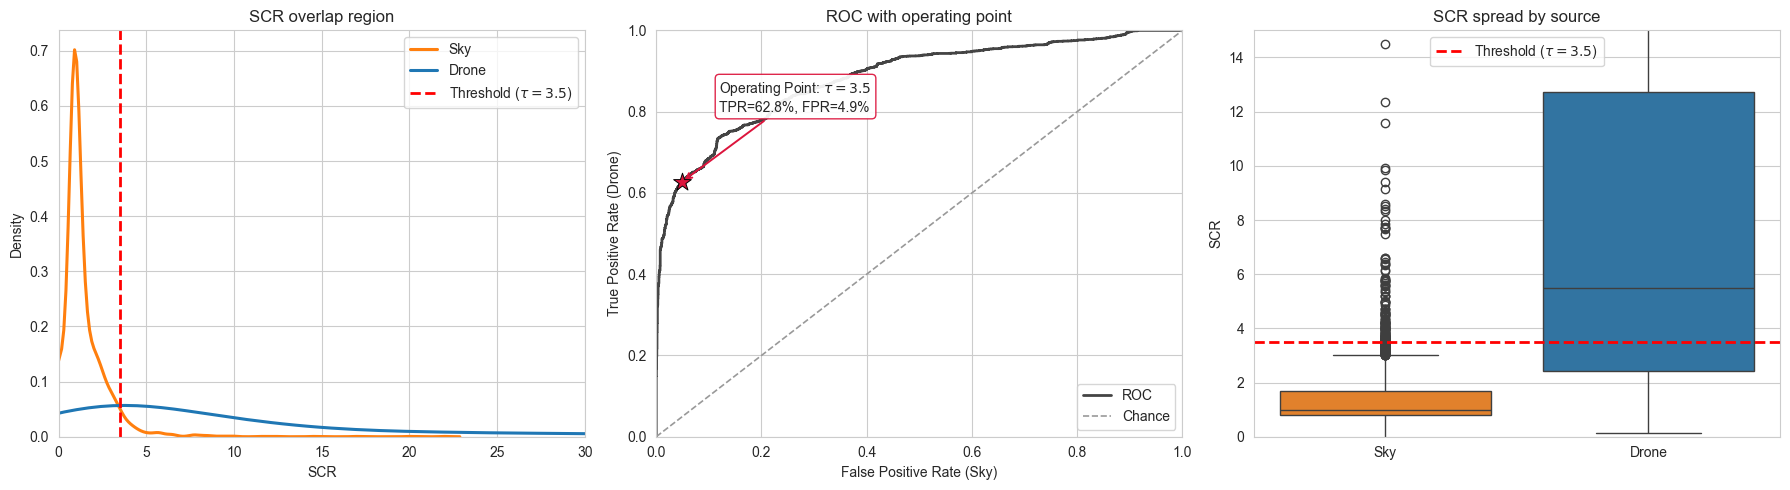

tau_fixed = 3.5
TPR at tau=3.5: 0.6278
FPR at tau=3.5: 0.0493
Saved comparison figure to: eda_results\eda_exports\scr_tau35_comparison.png


In [19]:
# ── 9: Tau=3.5 comparison views ────────────────────────────────────────────────
# KDE, ROC operating point, and boxplots all tied to tau = 3.5.

from matplotlib.lines import Line2D

# Fixed operating threshold chosen from the sky tail analysis.
tau_fixed = 3.5
scr_drone_values = drone_scr["scr"]
scr_sky_values = sky_scr["scr"]

# Threshold-derived operating point at tau = 3.5.
tpr_at_tau = float(np.mean(scr_drone_values > tau_fixed))
fpr_at_tau = float(np.mean(scr_sky_values > tau_fixed))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: KDE curves on a linear axis, zoomed to the overlap region.
ax = axes[0]
sns.kdeplot(scr_sky_values, color="#ff7f0e", linewidth=2.2, fill=False, label="Sky", ax=ax)
sns.kdeplot(scr_drone_values, color="#1f77b4", linewidth=2.2, fill=False, label="Drone", ax=ax)
ax.axvline(tau_fixed, color="red", linestyle="--", linewidth=2, label=r"Threshold ($\tau = 3.5$)")
ax.set_xlim(0, 30)
ax.set_xlabel("SCR")
ax.set_ylabel("Density")
ax.set_title("SCR overlap region")
ax.legend(frameon=True)

# Panel 2: ROC curve with the selected operating point highlighted.
ax = axes[1]
ax.plot(fpr_values, tpr_values, color="#444444", linewidth=2.0, label="ROC")
ax.plot([0, 1], [0, 1], linestyle="--", color="#999999", linewidth=1.2, label="Chance")
ax.scatter([fpr_at_tau], [tpr_at_tau], s=180, marker="*", color="crimson", edgecolors="black", linewidths=0.7, zorder=5)
ax.annotate(
    f"Operating Point: $\\tau = 3.5$\nTPR={tpr_at_tau:.1%}, FPR={fpr_at_tau:.1%}",
    xy=(fpr_at_tau, tpr_at_tau),
    xytext=(0.12, 0.80),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="crimson", lw=1.4),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", alpha=0.92),
)
ax.set_xlabel("False Positive Rate (Sky)")
ax.set_ylabel("True Positive Rate (Drone)")
ax.set_title("ROC with operating point")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=True, loc="lower right")

# Panel 3: Boxplots showing the spread of SCR values, capped for readability.
ax = axes[2]
sns.boxplot(data=[scr_sky_values, scr_drone_values], palette=["#ff7f0e", "#1f77b4"], ax=ax)
ax.axhline(tau_fixed, color="red", linestyle="--", linewidth=2, label=r"Threshold ($\tau = 3.5$)")
ax.set_ylim(0, 15)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Sky", "Drone"])
ax.set_ylabel("SCR")
ax.set_title("SCR spread by source")
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(EDA_EXPORT_DIR, "scr_tau35_comparison.png"), dpi=160)
plt.show()

print(f"tau_fixed = {tau_fixed:.1f}")
print(f"TPR at tau=3.5: {tpr_at_tau:.4f}")
print(f"FPR at tau=3.5: {fpr_at_tau:.4f}")
print(f"Saved comparison figure to: {os.path.join(EDA_EXPORT_DIR, 'scr_tau35_comparison.png')}")


In [46]:
# ── 10: Hoyer sparsity on core patches ──────────────────────────────────────────
# Compute Hoyer on the 31x31 core patches after subtracting each patch's ring mean.

HOYER_CORE_SIZE = PATCH_CORE * PATCH_CORE
HOYER_SQRT_N = float(np.sqrt(HOYER_CORE_SIZE))


def collect_hoyer_terms(core_patches, ring_patches):
    hoyer_values = []
    l1_values = []
    l2_values = []
    ring_mean_values = []
    zero_l2_count = 0

    for core, ring in zip(core_patches, ring_patches):
        core_f = core.astype(np.float32).reshape(-1)
        ring_f = ring.astype(np.float32).reshape(-1)
        ring_mean = float(np.mean(ring_f))
        ring_std = float(np.std(ring_f))
        core_centered = np.maximum(0.0, core_f - ring_mean)

        l1 = float(np.sum(np.abs(core_centered)))
        l2 = float(np.linalg.norm(core_centered, ord=2))

        if l2 <= 0.0:
            hoyer = 0.0
            zero_l2_count += 1
        else:
            raw_hoyer = (HOYER_SQRT_N - (l1 / l2)) / (HOYER_SQRT_N - 1.0)
            expected_noise_l2 = np.sqrt(len(core_centered) / 2.0) * ring_std
            excess_l2 = np.maximum(0.0, l2 - expected_noise_l2)
            energy_weight = excess_l2 / (excess_l2 + expected_noise_l2 + 1e-6)
            hoyer = raw_hoyer * energy_weight

        hoyer_values.append(hoyer)
        l1_values.append(l1)
        l2_values.append(l2)
        ring_mean_values.append(ring_mean)

    return {
        "hoyer": np.asarray(hoyer_values, dtype=np.float32),
        "l1": np.asarray(l1_values, dtype=np.float32),
        "l2": np.asarray(l2_values, dtype=np.float32),
        "ring_mean": np.asarray(ring_mean_values, dtype=np.float32),
        "zero_l2_count": int(zero_l2_count),
    }


def summarize_metric(values):
    return {
        "count": int(values.size),
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
        "median": float(np.median(values)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    }


drone_hoyer = collect_hoyer_terms(drone_core_patches, drone_ring_patches)
sky_hoyer = collect_hoyer_terms(sky_core_patches, sky_ring_patches)

hoyer_summary = {
    "drone": summarize_metric(drone_hoyer["hoyer"]),
    "sky": summarize_metric(sky_hoyer["hoyer"]),
    "meta": {
        "core_size": int(HOYER_CORE_SIZE),
        "sqrt_n": float(HOYER_SQRT_N),
        "ring_centering": "core_minus_ring_mean",
        "drone_zero_l2_count": int(drone_hoyer["zero_l2_count"]),
        "sky_zero_l2_count": int(sky_hoyer["zero_l2_count"]),
    },
}

np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "hoyer_metrics.npz"),
    drone_hoyer=drone_hoyer["hoyer"],
    drone_l1=drone_hoyer["l1"],
    drone_l2=drone_hoyer["l2"],
    drone_ring_mean=drone_hoyer["ring_mean"],
    sky_hoyer=sky_hoyer["hoyer"],
    sky_l1=sky_hoyer["l1"],
    sky_l2=sky_hoyer["l2"],
    sky_ring_mean=sky_hoyer["ring_mean"],
)

with open(os.path.join(EDA_EXPORT_DIR, "hoyer_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(hoyer_summary, f, indent=2)

print(f"Hoyer saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_metrics.npz')}")
print(f"Hoyer summary saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_metrics.json')}")
print("Hoyer normalization: subtract ring mean from each core before L1/L2")
print(f"Drone cores: {drone_hoyer['hoyer'].size}  zero-L2: {drone_hoyer['zero_l2_count']}")
print(f"Sky cores  : {sky_hoyer['hoyer'].size}  zero-L2: {sky_hoyer['zero_l2_count']}")
print(f"Drone Hoyer mean={hoyer_summary['drone']['mean']:.4f} median={hoyer_summary['drone']['median']:.4f}")
print(f"Sky Hoyer   mean={hoyer_summary['sky']['mean']:.4f} median={hoyer_summary['sky']['median']:.4f}")

Hoyer saved to: eda_results\eda_exports\hoyer_metrics.npz
Hoyer summary saved to: eda_results\eda_exports\hoyer_metrics.json
Hoyer normalization: subtract ring mean from each core before L1/L2
Drone cores: 3052  zero-L2: 0
Sky cores  : 2778  zero-L2: 203
Drone Hoyer mean=0.2256 median=0.1139
Sky Hoyer   mean=0.0184 median=0.0000


In [47]:
# ── 11: Hoyer statistics ───────────────────────────────────────────────────────
# Report descriptive statistics and a threshold-free separation summary.

sky_hoyer_values = sky_hoyer["hoyer"]
drone_hoyer_values = drone_hoyer["hoyer"]


def iqr(values):
    q25, q75 = np.percentile(values, [25, 75])
    return float(q75 - q25)


def percentile_map(values, percentiles):
    pct_values = np.percentile(values, percentiles)
    return {f"p{int(p)}": float(v) for p, v in zip(percentiles, pct_values)}


def summarize_distribution(values, percentiles):
    return {
        "count": int(values.size),
        "mean": float(np.mean(values)),
        "median": float(np.median(values)),
        "std": float(np.std(values)),
        "iqr": iqr(values),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
        "percentiles": percentile_map(values, percentiles),
    }


def estimate_auc(positive_scores, negative_scores):
    # AUROC equals the probability that a random drone score exceeds a random sky score.
    comparisons = (positive_scores[:, None] > negative_scores[None, :]).mean()
    ties = (positive_scores[:, None] == negative_scores[None, :]).mean()
    return float(comparisons + 0.5 * ties)


SKY_PERCENTILES = np.array([90, 95, 99], dtype=np.float32)
DRONE_PERCENTILES = np.array([10, 25, 50], dtype=np.float32)

sky_pct = percentile_map(sky_hoyer_values, SKY_PERCENTILES)
drone_pct = percentile_map(drone_hoyer_values, DRONE_PERCENTILES)

hoyer_statistics = {
    "drone": summarize_distribution(drone_hoyer_values, DRONE_PERCENTILES),
    "sky": summarize_distribution(sky_hoyer_values, SKY_PERCENTILES),
}

hoyer_statistics["separation"] = {
    "auroc": estimate_auc(drone_hoyer_values, sky_hoyer_values),
    "drone_p10_minus_sky_p90": drone_pct["p10"] - sky_pct["p90"],
    "drone_p25_minus_sky_p95": drone_pct["p25"] - sky_pct["p95"],
    "drone_p50_minus_sky_p99": drone_pct["p50"] - sky_pct["p99"],
}

with open(os.path.join(EDA_EXPORT_DIR, "hoyer_statistics.json"), "w", encoding="utf-8") as f:
    json.dump(hoyer_statistics, f, indent=2)

np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "hoyer_statistics.npz"),
    drone_hoyer_values=drone_hoyer_values.astype(np.float32),
    sky_hoyer_values=sky_hoyer_values.astype(np.float32),
    drone_selected_percentiles=np.array([drone_pct["p10"], drone_pct["p25"], drone_pct["p50"]], dtype=np.float32),
    sky_selected_percentiles=np.array([sky_pct["p90"], sky_pct["p95"], sky_pct["p99"]], dtype=np.float32),
    separation_auc=np.array([hoyer_statistics["separation"]["auroc"]], dtype=np.float32),
)

print(f"Hoyer statistics saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_statistics.json')}")
print(f"Hoyer statistic arrays saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_statistics.npz')}")
print("\nDrone summary:")
print(f"  mean={hoyer_statistics['drone']['mean']:.4f}  median={hoyer_statistics['drone']['median']:.4f}  std={hoyer_statistics['drone']['std']:.4f}  iqr={hoyer_statistics['drone']['iqr']:.4f}")
print(f"  P10={drone_pct['p10']:.4f}  P25={drone_pct['p25']:.4f}  P50={drone_pct['p50']:.4f}")
print("\nSky summary:")
print(f"  mean={hoyer_statistics['sky']['mean']:.4f}  median={hoyer_statistics['sky']['median']:.4f}  std={hoyer_statistics['sky']['std']:.4f}  iqr={hoyer_statistics['sky']['iqr']:.4f}")
print(f"  P90={sky_pct['p90']:.4f}  P95={sky_pct['p95']:.4f}  P99={sky_pct['p99']:.4f}")
print("\nSeparation summary:")
print(f"  AUROC={hoyer_statistics['separation']['auroc']:.4f}")
print(f"  drone P10 - sky P90 = {hoyer_statistics['separation']['drone_p10_minus_sky_p90']:.4f}")
print(f"  drone P25 - sky P95 = {hoyer_statistics['separation']['drone_p25_minus_sky_p95']:.4f}")
print(f"  drone P50 - sky P99 = {hoyer_statistics['separation']['drone_p50_minus_sky_p99']:.4f}")


Hoyer statistics saved to: eda_results\eda_exports\hoyer_statistics.json
Hoyer statistic arrays saved to: eda_results\eda_exports\hoyer_statistics.npz

Drone summary:
  mean=0.2256  median=0.1139  std=0.2488  iqr=0.4028
  P10=0.0000  P25=0.0000  P50=0.1139

Sky summary:
  mean=0.0184  median=0.0000  std=0.0563  iqr=0.0000
  P90=0.0641  P95=0.1368  P99=0.2705

Separation summary:
  AUROC=0.7593
  drone P10 - sky P90 = -0.0641
  drone P25 - sky P95 = -0.1368
  drone P50 - sky P99 = -0.1566


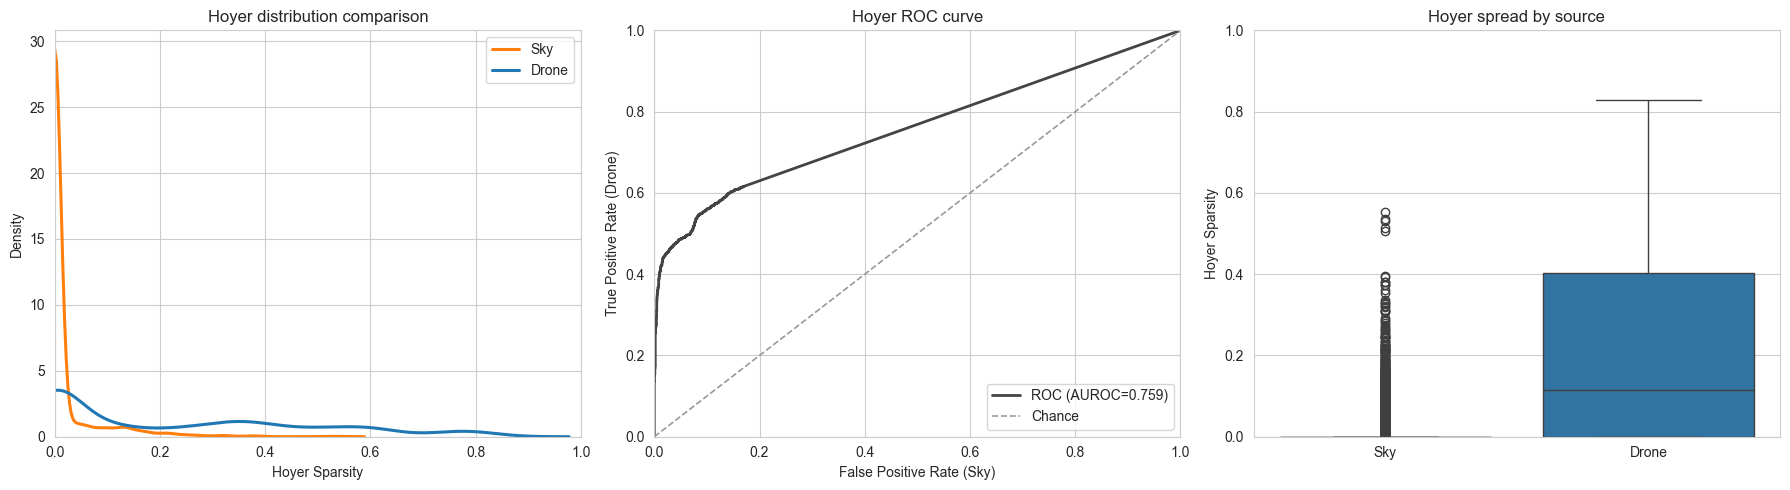

Hoyer comparison figure saved to: eda_results\eda_exports\hoyer_comparison.png
Hoyer AUROC: 0.7593


In [48]:
# ── 12: Hoyer comparison plots ─────────────────────────────────────────────────
# Compare drone and sky Hoyer distributions without selecting a fixed threshold.


def estimate_roc_curve(positive_scores, negative_scores):
    thresholds = np.unique(np.concatenate([positive_scores, negative_scores]))
    thresholds = np.sort(thresholds)
    tpr = np.array([np.mean(positive_scores >= tau) for tau in thresholds], dtype=np.float32)
    fpr = np.array([np.mean(negative_scores >= tau) for tau in thresholds], dtype=np.float32)
    return thresholds, tpr, fpr


hoyer_thresholds_plot, hoyer_tpr_plot, hoyer_fpr_plot = estimate_roc_curve(drone_hoyer_values, sky_hoyer_values)
hoyer_auc_plot = estimate_auc(drone_hoyer_values, sky_hoyer_values)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: KDE comparison on the natural Hoyer range.
ax = axes[0]
sns.kdeplot(sky_hoyer_values, color="#ff7f0e", linewidth=2.2, fill=False, label="Sky", ax=ax)
sns.kdeplot(drone_hoyer_values, color="#1f77b4", linewidth=2.2, fill=False, label="Drone", ax=ax)
ax.set_xlim(0, 1)
ax.set_xlabel("Hoyer Sparsity")
ax.set_ylabel("Density")
ax.set_title("Hoyer distribution comparison")
ax.legend(frameon=True)

# Panel 2: ROC curve without a fixed operating threshold.
ax = axes[1]
ax.plot(hoyer_fpr_plot, hoyer_tpr_plot, color="#444444", linewidth=2.0, label=f"ROC (AUROC={hoyer_auc_plot:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="#999999", linewidth=1.2, label="Chance")
ax.set_xlabel("False Positive Rate (Sky)")
ax.set_ylabel("True Positive Rate (Drone)")
ax.set_title("Hoyer ROC curve")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=True, loc="lower right")

# Panel 3: Boxplots of Hoyer values by source.
ax = axes[2]
sns.boxplot(data=[sky_hoyer_values, drone_hoyer_values], palette=["#ff7f0e", "#1f77b4"], ax=ax)
ax.set_ylim(0, 1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Sky", "Drone"])
ax.set_ylabel("Hoyer Sparsity")
ax.set_title("Hoyer spread by source")

plt.tight_layout()
plt.savefig(os.path.join(EDA_EXPORT_DIR, "hoyer_comparison.png"), dpi=160)
plt.show()

print(f"Hoyer comparison figure saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_comparison.png')}")
print(f"Hoyer AUROC: {hoyer_auc_plot:.4f}")


In [49]:
# ── 13: Hoyer hypothesis tests (drone vs sky) ─────────────────────────────────
# Compare the Hoyer distributions with a mean test and a median-focused test.

from scipy import stats as scipy_stats

drone_hoyer_arr = np.asarray(drone_hoyer_values, dtype=np.float64)
sky_hoyer_arr = np.asarray(sky_hoyer_values, dtype=np.float64)

drone_hoyer_arr = drone_hoyer_arr[np.isfinite(drone_hoyer_arr)]
sky_hoyer_arr = sky_hoyer_arr[np.isfinite(sky_hoyer_arr)]

welch_t = scipy_stats.ttest_ind(
    drone_hoyer_arr,
    sky_hoyer_arr,
    equal_var=False,
    alternative="two-sided",
)

drone_mean = float(np.mean(drone_hoyer_arr))
sky_mean = float(np.mean(sky_hoyer_arr))
mean_diff = float(drone_mean - sky_mean)
drone_var = float(np.var(drone_hoyer_arr, ddof=1))
sky_var = float(np.var(sky_hoyer_arr, ddof=1))
drone_n = int(drone_hoyer_arr.size)
sky_n = int(sky_hoyer_arr.size)

welch_df_num = (drone_var / drone_n + sky_var / sky_n) ** 2
welch_df_den = ((drone_var / drone_n) ** 2) / (drone_n - 1) + ((sky_var / sky_n) ** 2) / (sky_n - 1)
welch_df = float(welch_df_num / welch_df_den)

mean_diff_se = float(np.sqrt(drone_var / drone_n + sky_var / sky_n))
t_crit = float(scipy_stats.t.ppf(0.975, welch_df))
ci_low = mean_diff - t_crit * mean_diff_se
ci_high = mean_diff + t_crit * mean_diff_se

pooled_sd = float(np.sqrt(((drone_n - 1) * drone_var + (sky_n - 1) * sky_var) / (drone_n + sky_n - 2)))
cohens_d = float(mean_diff / pooled_sd) if pooled_sd > 0 else 0.0

drone_median = float(np.median(drone_hoyer_arr))
sky_median = float(np.median(sky_hoyer_arr))
median_diff = float(drone_median - sky_median)
median_statistic, median_pvalue, global_median, median_table = scipy_stats.median_test(
    drone_hoyer_arr,
    sky_hoyer_arr,
    ties="below",
)

hoyer_tests = {
    "mean_test": {
        "test": "Welch two-sample t-test",
        "null_hypothesis": "drone and sky Hoyer means are equal",
        "drone_count": drone_n,
        "sky_count": sky_n,
        "drone_mean": drone_mean,
        "sky_mean": sky_mean,
        "mean_difference": mean_diff,
        "t_statistic": float(welch_t.statistic),
        "p_value": float(welch_t.pvalue),
        "degrees_of_freedom": welch_df,
        "mean_difference_95ci": [float(ci_low), float(ci_high)],
        "cohens_d": cohens_d,
    },
    "median_test": {
        "test": "Mood median test",
        "null_hypothesis": "drone and sky Hoyer medians are equal",
        "drone_count": drone_n,
        "sky_count": sky_n,
        "drone_median": drone_median,
        "sky_median": sky_median,
        "median_difference": median_diff,
        "grand_median": float(global_median),
        "chi2_statistic": float(median_statistic),
        "p_value": float(median_pvalue),
        "contingency_table": median_table.astype(int).tolist(),
    },
}

with open(os.path.join(EDA_EXPORT_DIR, "hoyer_ttest.json"), "w", encoding="utf-8") as f:
    json.dump(hoyer_tests, f, indent=2)

np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "hoyer_ttest.npz"),
    drone_hoyer_values=drone_hoyer_arr.astype(np.float32),
    sky_hoyer_values=sky_hoyer_arr.astype(np.float32),
    t_statistic=np.array([hoyer_tests["mean_test"]["t_statistic"]], dtype=np.float32),
    t_p_value=np.array([hoyer_tests["mean_test"]["p_value"]], dtype=np.float64),
    degrees_of_freedom=np.array([hoyer_tests["mean_test"]["degrees_of_freedom"]], dtype=np.float32),
    mean_difference=np.array([hoyer_tests["mean_test"]["mean_difference"]], dtype=np.float32),
    cohens_d=np.array([hoyer_tests["mean_test"]["cohens_d"]], dtype=np.float32),
    median_chi2=np.array([hoyer_tests["median_test"]["chi2_statistic"]], dtype=np.float32),
    median_p_value=np.array([hoyer_tests["median_test"]["p_value"]], dtype=np.float64),
    drone_median=np.array([hoyer_tests["median_test"]["drone_median"]], dtype=np.float32),
    sky_median=np.array([hoyer_tests["median_test"]["sky_median"]], dtype=np.float32),
    median_difference=np.array([hoyer_tests["median_test"]["median_difference"]], dtype=np.float32),
    grand_median=np.array([hoyer_tests["median_test"]["grand_median"]], dtype=np.float32),
)

print(f"Hoyer hypothesis tests saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_ttest.json')}")
print(f"Hoyer hypothesis test arrays saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_ttest.npz')}")
print("\nWelch two-sample t-test:")
print(f"  drone mean = {hoyer_tests['mean_test']['drone_mean']:.4f}")
print(f"  sky mean   = {hoyer_tests['mean_test']['sky_mean']:.4f}")
print(f"  mean diff  = {hoyer_tests['mean_test']['mean_difference']:.4f}")
print(f"  t = {hoyer_tests['mean_test']['t_statistic']:.4f}")
print(f"  df = {hoyer_tests['mean_test']['degrees_of_freedom']:.2f}")
print(f"  p-value = {hoyer_tests['mean_test']['p_value']:.6g}")
print(f"  95% CI for mean diff = [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  Cohen's d = {hoyer_tests['mean_test']['cohens_d']:.4f}")

print("\nMood median test:")
print(f"  drone median = {hoyer_tests['median_test']['drone_median']:.4f}")
print(f"  sky median   = {hoyer_tests['median_test']['sky_median']:.4f}")
print(f"  median diff  = {hoyer_tests['median_test']['median_difference']:.4f}")
print(f"  grand median = {hoyer_tests['median_test']['grand_median']:.4f}")
print(f"  chi2 = {hoyer_tests['median_test']['chi2_statistic']:.4f}")
print(f"  p-value = {hoyer_tests['median_test']['p_value']:.6g}")

Hoyer hypothesis tests saved to: eda_results\eda_exports\hoyer_ttest.json
Hoyer hypothesis test arrays saved to: eda_results\eda_exports\hoyer_ttest.npz

Welch two-sample t-test:
  drone mean = 0.2256
  sky mean   = 0.0184
  mean diff  = 0.2072
  t = 44.7561
  df = 3391.90
  p-value = 0
  95% CI for mean diff = [0.1981, 0.2162]
  Cohen's d = 1.1248

Mood median test:
  drone median = 0.1139
  sky median   = 0.0000
  median diff  = 0.1139
  grand median = 0.0000
  chi2 = 1200.5501
  p-value = 4.63186e-263
